**Making Sure if we are in the same directory, where the file is located**

In [1]:
import os
os.chdir("..")
print("Now cwd is:", os.getcwd())
print("data_raw exists now?", os.path.exists("data_raw"))

Now cwd is: /workspaces/ml-anomaly-detection-cloud-systems
data_raw exists now? True


**Importing/loading the datsaet to have a glimpse of it**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [3]:
path = "data_raw/nab/data/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv"
df = pd.read_csv(path)
print(df.columns)
df.head()

Index(['timestamp', 'value'], dtype='object')


,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714


Changing the "timestamp" to time

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()

,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714


In [5]:
# Save cleaned real cloud data
df_clean = df[["timestamp", "value"]].copy()
df_clean.to_csv(
    "data_processed/aws_cloudwatch/cpu_cleaned.csv",
    index=False)

Plotting the real System behaviour

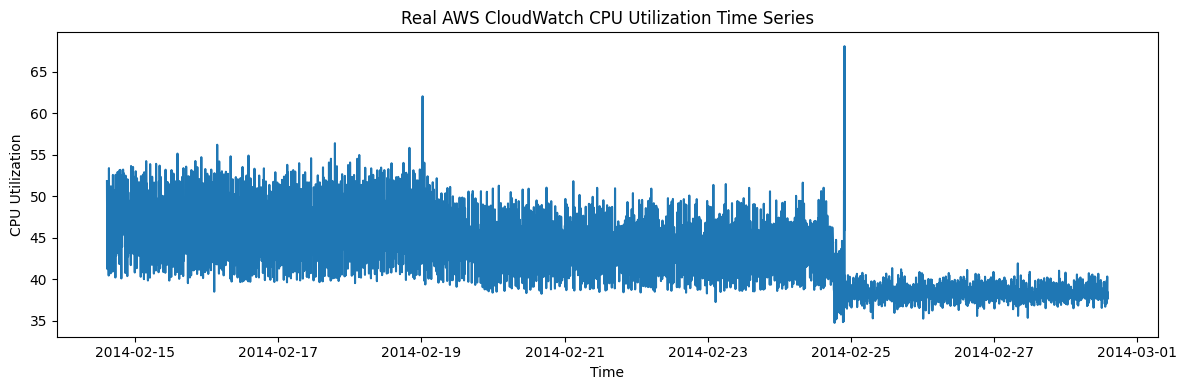

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["value"])
plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.title("Real AWS CloudWatch CPU Utilization Time Series")
plt.tight_layout()
plt.show()

**Applying Z-Score and Visualizing Z-score anomolies**

In [7]:
mean_val = df["value"].mean()
std_val = df["value"].std()

df["z_score"] = (df["value"] - mean_val) / std_val
df["z_anomaly"] = df["z_score"].abs() > 3

plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["value"], label="CPU Utilization")

plt.scatter(
    df.loc[df["z_anomaly"], "timestamp"],
    df.loc[df["z_anomaly"], "value"],
    color="red",
    s=40,
    label="Z-score anomalies")

plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.title("Z-score Anomaly Detection on Real Cloud Data")
plt.legend()
plt.tight_layout()
plt.savefig("results/aws_cloudwatch/zscore_anomalies.png", dpi=150)
plt.close()

**Saving the cleaned Real Cloud data (timestamp + value) to designated folder**

In [8]:
df_clean = df[["timestamp", "value"]].copy()

df_clean.to_csv("data_processed/aws_cloudwatch/cpu_cleaned.csv",
    index=False)

**Saving Z-score outputs**

In [9]:
# Saving Z-score outputs
df[["timestamp", "value", "z_score", "z_anomaly"]].to_csv(
    "data_processed/aws_cloudwatch/cpu_zscore_flags.csv",
    index=False)

**Creating Rolling feature and Saving Feature Data**

In [10]:
# Sorting by time
df = df.sort_values("timestamp").copy()

# Context features (24 points ≈ 24 samples; not "hours" unless sampling is hourly)
df["rolling_mean_24"] = df["value"].rolling(window=24).mean()
df["rolling_std_24"]  = df["value"].rolling(window=24).std()

# Droping rows where rolling stats are not available
df_model = df.dropna().copy()

df_model.head()

,timestamp,value,z_score,z_anomaly,rolling_mean_24,rolling_std_24
23,2014-02-14 16:22:00,40.942,-0.503855,False,46.325667,3.655012
24,2014-02-14 16:27:00,52.586,2.201809,False,46.356500,3.706366
25,2014-02-14 16:32:00,45.802,0.625442,False,46.410417,3.687672
26,2014-02-14 16:37:00,43.122,0.002702,False,46.488667,3.591960
27,2014-02-14 16:42:00,50.774,1.780763,False,46.580583,3.674754


In [11]:
df_model[["timestamp", "value", "rolling_mean_24", "rolling_std_24"]].to_csv(
    "data_processed/aws_cloudwatch/cpu_features.csv",
    index=False)

**Running Isolation Forest and saving it's flags**

In [12]:
from sklearn.ensemble import IsolationForest

X_real = df_model[["value", "rolling_mean_24", "rolling_std_24"]]

iso_real = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42)

iso_real.fit(X_real)

df_model["iforest_anomaly"] = (iso_real.predict(X_real) == -1)

In [13]:
df_model[["timestamp", "value", "iforest_anomaly"]].to_csv(
    "data_processed/aws_cloudwatch/cpu_iforest_flags.csv",
    index=False)

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(df_model["timestamp"], df_model["value"], label="CPU Utilization")

plt.scatter(
    df_model.loc[df_model["iforest_anomaly"], "timestamp"],
    df_model.loc[df_model["iforest_anomaly"], "value"],
    s=40,
    label="Isolation Forest anomalies"
)

plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.title("Isolation Forest on Real AWS CloudWatch Data")
plt.legend()
plt.tight_layout()
plt.savefig("results/aws_cloudwatch/iforest_anomalies.png", dpi=150)
plt.close()

**Forecast-Based Anomaly Detection (Residual Analysis)**

In [15]:
df = df.sort_values("timestamp").copy()

window = 24
df["forecast_ma24"] = df["value"].rolling(window=window).mean().shift(1)
df["residual"] = df["value"] - df["forecast_ma24"]

df_f = df.dropna(subset=["forecast_ma24", "residual"]).copy()
df_f[["timestamp", "value", "forecast_ma24", "residual"]].head()

,timestamp,value,forecast_ma24,residual
24,2014-02-14 16:27:00,52.586,46.325667,6.260333
25,2014-02-14 16:32:00,45.802,46.356500,-0.554500
26,2014-02-14 16:37:00,43.122,46.410417,-3.288417
27,2014-02-14 16:42:00,50.774,46.488667,4.285333
28,2014-02-14 16:47:00,46.262,46.580583,-0.318583


In [ ]:
abs_res = df_f["residual"].abs()

# Flagging the most extreme 0.5% residuals as anomalies
thr = abs_res.quantile(0.995)

df_f["forecast_anomaly"] = abs_res > thr

thr, df_f["forecast_anomaly"].mean()

(np.float64(8.02982458333333), np.float64(0.005239520958083832))

In [17]:
# Saving the forcast in csv file
df_f[["timestamp", "value", "forecast_ma24", "residual", "forecast_anomaly"]].to_csv(
    "data_processed/aws_cloudwatch/cpu_forecast_residuals.csv",
    index=False)

In [18]:
# Plotting the forcast

plt.figure(figsize=(12, 4))
plt.plot(df_f["timestamp"], df_f["value"], label="Actual")
plt.plot(df_f["timestamp"], df_f["forecast_ma24"], label="Forecast (MA24)")

plt.scatter(
    df_f.loc[df_f["forecast_anomaly"], "timestamp"],
    df_f.loc[df_f["forecast_anomaly"], "value"],
    s=40,
    label="Residual anomalies"
)

plt.xlabel("Time")
plt.ylabel("CPU Utilization")
plt.title("Forecast Residual Anomalies (Moving Average Baseline)")
plt.legend()
plt.tight_layout()
plt.savefig("results/aws_cloudwatch/forecast_residual_anomalies.png", dpi=150)
plt.close()